# Country Development Clustering Project

In this project, we analyze socio-economic and health indicators of 167 countries to identify patterns of development using clustering techniques.

The goal is to group countries based on their development profile and recommend which countries are in the most urgent need of financial aid for humanitarian support.

## Data Loading

In this step, we load the dataset and convert it into a Pandas DataFrame for further analysis and preprocessing.

In [2]:
import os
import pandas as pd

path = os.path.join("..", "data", "Country-data.csv")
df = pd.read_csv(path)

## Initial Data Inspection

We now explore the dataset structure using basic Pandas functions such as `head()`, `info()`, and `describe()` to understand the data types, summary statistics, and overall structure.

In [7]:
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


## Data Understanding and Cleaning

In this section, we examine the dataset structure, check for missing and duplicate values, verify country uniqueness, and explore the distribution and scale of the variables before preprocessing and clustering.

In [12]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No missing values were found in the dataset.

In [13]:
df.duplicated().sum()

np.int64(0)

No duplicated rows were found in the dataset.

In [15]:
df['country'].nunique(),len(df)

167 167


The number of unique countries is equal to the number of rows, which confirms that each row represents a unique country.

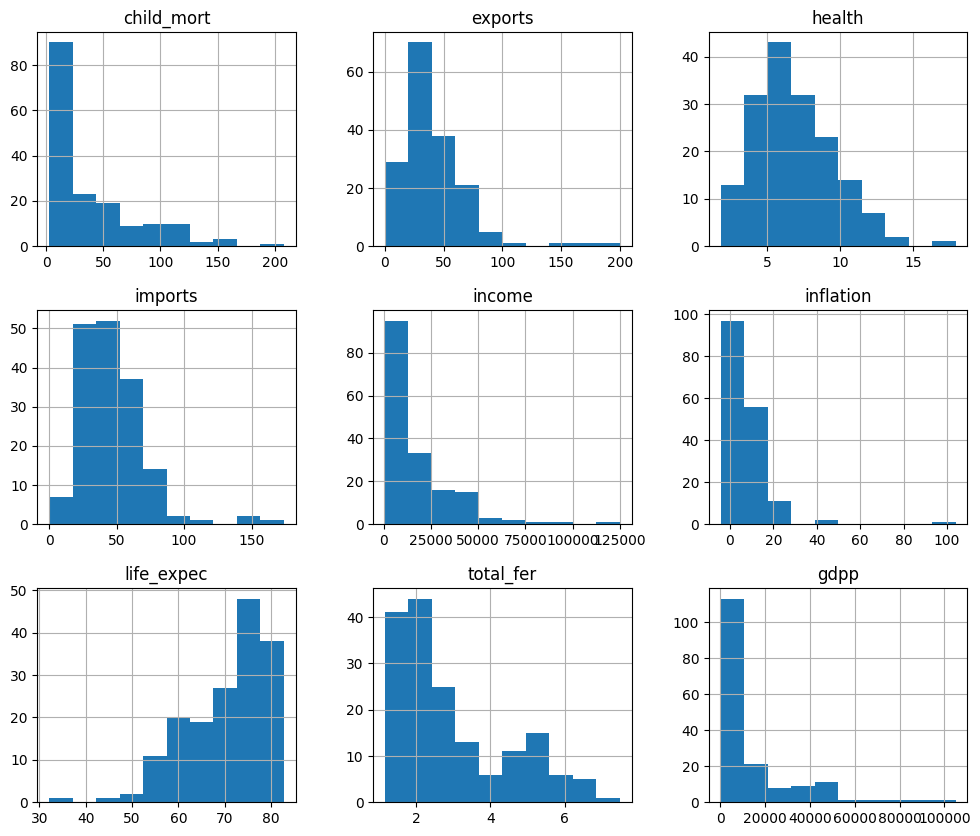

In [22]:
import seaborn
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

The distributions show noticeable differences in scale and spread across variables.

- `exports` contains a few outliers and ranges roughly from 0 to 200.
- `child_mort` has several extreme outliers and ranges up to around 200.
- `health` is relatively stable with only a small number of possible outliers and ranges from 0 to around 15.
- `income` contains strong outliers and spans a very large range, reaching above 125,000
- `imports` has several outliers and ranges up to around 150.
- `life_expec` contains a few outliers and reaches around 80 years.
- `total_fer` is relatively balanced with limited outliers and ranges up to around 7.
- `gdpp` shows a highly skewed distribution with major outliers reaching around 100,000.
- `inflation` has a few significant outliers and ranges up to nearly 100.
    